# Rapport Final d'Analyse des Accidents Aériens (1908-2023)

In [15]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('/content/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')
data.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [3]:
print("Nombre de lignes et de colonnes :", data.shape)

Nombre de lignes et de colonnes : (4998, 17)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Grou

In [5]:
print(data.duplicated().sum())

0


il n'y a aucune ligne en doublon dans le dataset

In [6]:
print(data.isnull().sum())

Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
dtype: int64


In [7]:
missing_rate = round(data.isnull().sum() / len(data),4) * 100
print(missing_rate)

Date                      0.00
Time                     30.25
Location                  0.08
Operator                  0.20
Flight #                 73.41
Route                    15.55
AC Type                   0.30
Registration              5.48
cn/ln                    13.37
Aboard                    0.36
Aboard Passangers         4.58
Aboard Crew               4.52
Fatalities                0.16
Fatalities Passangers     4.84
Fatalities Crew           4.82
Ground                    0.84
Summary                   1.28
dtype: float64


In [8]:
data['Date'] = pd.to_datetime(data['Date'])

numeric_cols = data.select_dtypes(include=['float64']).columns
data[numeric_cols] = data[numeric_cols].fillna(0)

object_cols = data.select_dtypes(include=['object']).columns
data[object_cols] = data[object_cols].fillna('none')


print(data.isnull().sum())


Date                     0
Time                     0
Location                 0
Operator                 0
Flight #                 0
Route                    0
AC Type                  0
Registration             0
cn/ln                    0
Aboard                   0
Aboard Passangers        0
Aboard Crew              0
Fatalities               0
Fatalities Passangers    0
Fatalities Crew          0
Ground                   0
Summary                  0
dtype: int64


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   4998 non-null   datetime64[ns]
 1   Time                   4998 non-null   object        
 2   Location               4998 non-null   object        
 3   Operator               4998 non-null   object        
 4   Flight #               4998 non-null   object        
 5   Route                  4998 non-null   object        
 6   AC Type                4998 non-null   object        
 7   Registration           4998 non-null   object        
 8   cn/ln                  4998 non-null   object        
 9   Aboard                 4998 non-null   float64       
 10  Aboard Passangers      4998 non-null   float64       
 11  Aboard Crew            4998 non-null   float64       
 12  Fatalities             4998 non-null   float64       
 13  Fat

In [10]:
print("Nombre de lignes et de colonnes :", data.shape)

Nombre de lignes et de colonnes : (4998, 17)


## Résumé des Données et Nettoyage
L'ensemble de données contient **4998 accidents** documentés. Les valeurs manquantes ont été traitées : les données numériques absentes ont été remplacées par 0, et les données textuelles par la mention 'none'.


In [11]:
total_accidents = len(data)
total_aboard = data['Aboard'].sum()
total_fatalities = data['Fatalities'].sum()
survival_rate = ((total_aboard - total_fatalities) / total_aboard) * 100

print(f"Total Accidents: {total_accidents}")
print(f"Total Fatalities: {total_fatalities:.0f}")
print(f"Overall Survival Rate: {survival_rate:.2f}% \n")

data['Year'] = data['Date'].dt.year
accidents_per_year = data.groupby('Year').size()
accidents_per_year

Total Accidents: 4998
Total Fatalities: 111644
Overall Survival Rate: 28.14% 



,0
Year,
1908,1
1909,1
1912,1
1913,3
1915,2
...,...
2019,13
2020,8
2021,9


Analyse des Décès

In [12]:
fatalities_mean = data['Fatalities'].mean()
fatalities_median = data['Fatalities'].median()
fatalities_std = data['Fatalities'].std()

print(f"Fatalities Mean: {fatalities_mean:.2f}")
print(f"Fatalities Median: {fatalities_median:.2f}")
print(f"Fatalities Standard Deviation: {fatalities_std:.2f}")


Fatalities Mean: 22.34
Fatalities Median: 11.00
Fatalities Standard Deviation: 35.05


Analyse des Personnes à Bord

In [13]:
aboard_mean = data['Aboard'].mean()
aboard_median = data['Aboard'].median()
aboard_std = data['Aboard'].std()

print(f"Aboard Mean: {aboard_mean:.2f}")
print(f"Aboard Median: {aboard_median:.2f}")
print(f"Aboard Standard Deviation: {aboard_std:.2f}")


Aboard Mean: 31.08
Aboard Median: 16.00
Aboard Standard Deviation: 45.49


### Analyse du Taux de Survie par Accident

In [18]:
data['survival_rate_per_accident'] = np.where(
    data['Aboard'] > 0,
    (data['Aboard'] - data['Fatalities']) / data['Aboard'],np.nan)

survival_rate_mean = data['survival_rate_per_accident'].mean()
survival_rate_median = data['survival_rate_per_accident'].median()
survival_rate_std = data['survival_rate_per_accident'].std()

print(f"Survival Rate per Accident Mean: {survival_rate_mean:.2%}")
print(f"Survival Rate per Accident Median: {survival_rate_median:.2%}")
print(f"Survival Rate per Accident Standard Deviation: {survival_rate_std:.2%}")


Survival Rate per Accident Mean: 18.15%
Survival Rate per Accident Median: 0.00%
Survival Rate per Accident Standard Deviation: 31.17%


## Statistiques Descriptives
*   **Nombre total de décès :** ~111 644.
*   **Taux de survie global :** ~28.14%.
*   **Moyenne de décès par accident :** ~22.34.
*   **Médiane de décès :** 11.00 (ce qui indique que la distribution est étalée vers la droite avec quelques accidents très meurtriers).


Test d'hypothèse: Comparer le nombre moyen de décès des deux dernières décenies

In [22]:
from scipy.stats import ttest_ind


data['Decade'] = (data['Date'].dt.year // 10) * 10

decade_1 = data[data['Decade'] == 2010]['Fatalities']
decade_2 = data[data['Decade'] == 2020]['Fatalities']

t_stat, p_value = ttest_ind(decade_1, decade_2, equal_var=False, nan_policy='omit')

print(f"T-test Results comparés de 2010s vs 2020s:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")


alpha = 0.05
if p_value < alpha:
    print("\nConclusion : Il existe une différence statistiquement significative entre le nombre moyen de décès enregistrés dans les années 2010 et ceux des années 2020.")
else:
    print("\nConclusion : Il n'existe pas une différence statistiquement significative  entre le nombre moyen de décès enregistrés dans les années 2010 et dans les années 2020.")

T-test Results comparés de 2010s vs 2020s:
T-statistic: -0.4006
P-value: 0.6913

Conclusion : Il n'existe pas une différence statistiquement significative  entre le nombre moyen de décès enregistrés dans les années 2010 et dans les années 2020.



## Tests Statistiques
*   **T-test (2010s vs 2020s) :**
    *   Statistique T : -0.4006 | P-value : 0.6913.
    *   **Conclusion :** Aucune différence statistiquement significative n'a été trouvée entre la moyenne des décès des années 2010 et 2020. La sécurité semble s'être stabilisée sur ces deux périodes.

/tmp/ipykernel_427/2435791563.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regions.values, y=top_regions.index, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_427/2435791563.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Decade', y='Fatalities', data=data_last_two_decades, ax=axes[1, 1], palette='Set2')


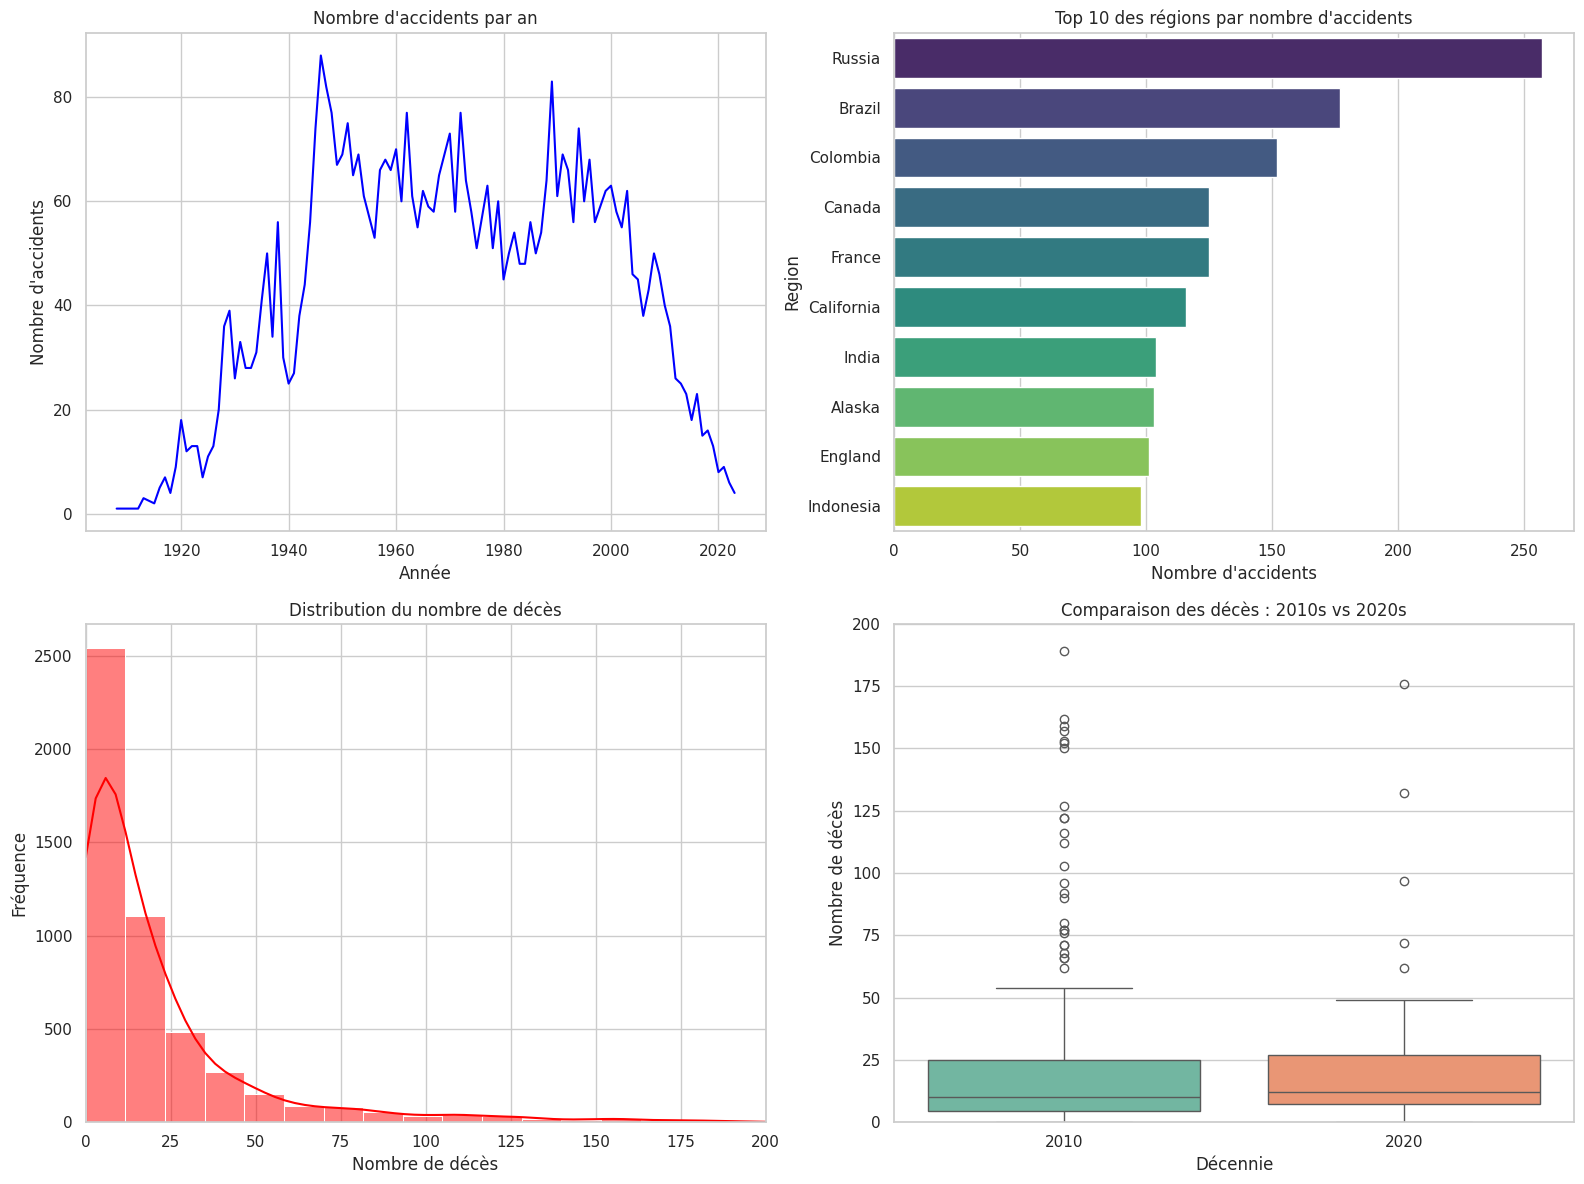

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


sns.lineplot(x=accidents_per_year.index, y=accidents_per_year.values, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Nombre d\'accidents par an')
axes[0, 0].set_xlabel('Année')
axes[0, 0].set_ylabel('Nombre d\'accidents')


data['Region'] = data['Location'].apply(lambda x: x.split(',')[-1].strip() if ',' in x else x)
top_regions = data['Region'].value_counts().head(10)
sns.barplot(x=top_regions.values, y=top_regions.index, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Top 10 des régions par nombre d\'accidents')
axes[0, 1].set_xlabel('Nombre d\'accidents')


sns.histplot(data['Fatalities'], bins=50, kde=True, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Distribution du nombre de décès')
axes[1, 0].set_xlabel('Nombre de décès')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_xlim(0, 200)


data_last_two_decades = data[data['Decade'].isin([2010, 2020])]
sns.boxplot(x='Decade', y='Fatalities', data=data_last_two_decades, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Comparaison des décès : 2010s vs 2020s')
axes[1, 1].set_xlabel('Décennie')
axes[1, 1].set_ylabel('Nombre de décès')
axes[1, 1].set_ylim(0, 200)

plt.tight_layout()
plt.show()

# Analyse des Tendances et Visualisations

Séries chronologiques : Le nombre d'accidents a connu un pic au milieu du XXe siècle avant de diminuer progressivement, reflétant l'amélioration de la sécurité aérienne malgré l'augmentation du trafic.

Géographie : La Russie, le Brésil et la Colombie figurent parmi les régions enregistrant le plus grand nombre d'accidents documentés.

Distribution : La majorité des accidents font moins de 50 victimes, mais les valeurs extrêmes influencent fortement la moyenne.

# Anomalies et Observations
*   Le taux de survie par accident médian est de **0%**, ce qui signifie que dans plus de la moitié des cas enregistrés, il n'y a aucun survivant.
*   On observe une forte variabilité dans les données (écart-type élevé), soulignant que les accidents aériens varient énormément en gravité (de petits appareils privés à de gros porteurs commerciaux).